In [1]:
# ============================================================
# 1. Imports & Config
# ============================================================
!pip install scikit-learn xgboost seaborn
import os
import gc
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from xgboost import XGBClassifier  # pip install xgboost if needed
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Optional: adjust display
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

RANDOM_STATE = 42
N_JOBS = -1


In [3]:
# ============================================================
# 2. Load Data
# ============================================================

DATA_DIR = "./data/nfl-player-contact-detection"  # TODO: change this

train_labels_path = os.path.join(DATA_DIR, "train_labels.csv")
train_tracking_path = os.path.join(DATA_DIR, "train_player_tracking.csv")
train_helmets_path = os.path.join(DATA_DIR, "train_baseline_helmets.csv")
train_video_meta_path = os.path.join(DATA_DIR, "train_video_metadata.csv")

# Your custom outcome labels
play_outcomes_path = os.path.join(DATA_DIR, "play_labels.csv")

train_labels = pd.read_csv(train_labels_path)
train_tracking = pd.read_csv(train_tracking_path)
train_helmets = pd.read_csv(train_helmets_path)
train_video_meta = pd.read_csv(train_video_meta_path)
play_outcomes = pd.read_csv(play_outcomes_path)

print("train_labels:", train_labels.shape)
print("train_tracking:", train_tracking.shape)
print("train_helmets:", train_helmets.shape)
print("train_video_meta:", train_video_meta.shape)
print("play_outcomes:", play_outcomes.shape)

train_labels.head()


train_labels: (4721618, 7)
train_tracking: (1353053, 17)
train_helmets: (3783616, 12)
train_video_meta: (480, 7)
play_outcomes: (240, 2)


,contact_id,game_play,datetime,step,nfl_player_id_1,nfl_player_id_2,contact
0,58168_003392_0_38590_43854,58168_003392,2020-09-11T03:01:48.100Z,0,38590,43854,0
1,58168_003392_0_38590_41257,58168_003392,2020-09-11T03:01:48.100Z,0,38590,41257,0
2,58168_003392_0_38590_41944,58168_003392,2020-09-11T03:01:48.100Z,0,38590,41944,0
3,58168_003392_0_38590_42386,58168_003392,2020-09-11T03:01:48.100Z,0,38590,42386,0
4,58168_003392_0_38590_47944,58168_003392,2020-09-11T03:01:48.100Z,0,38590,47944,0


In [4]:
play_outcomes['video_file_norm'] = play_outcomes['video_file'].str.replace('.mp4', '', regex=False)
train_video_meta['video_file_norm'] = (
    train_video_meta['game_key'].astype(str)
    + "_" +
    train_video_meta['play_id'].astype(str).str.zfill(6)
    + "_" +
    train_video_meta['view']
)
play_outcomes_mapped = (
    play_outcomes
    .merge(
        train_video_meta[['game_play', 'video_file_norm']],
        on='video_file_norm',
        how='left'
    )
)

print(play_outcomes_mapped[['video_file', 'video_file_norm', 'game_play']].head())
print("Rows with missing game_play:", play_outcomes_mapped['game_play'].isna().sum())


# Drop rows where we couldn't map to a game_play
play_outcomes_mapped = play_outcomes_mapped.dropna(subset=['game_play'])

# Keep a single row per play with the label
play_outcomes_gp = (
    play_outcomes_mapped[['game_play', 'label']]
    .drop_duplicates()
    .rename(columns={'label': 'outcome'})
)

print(play_outcomes_gp.head())
print("Unique game_play in mapped outcomes:", play_outcomes_gp['game_play'].nunique())


                  video_file        video_file_norm     game_play
0  58168_003392_Sideline.mp4  58168_003392_Sideline  58168_003392
1  58172_003247_Sideline.mp4  58172_003247_Sideline  58172_003247
2  58173_003606_Sideline.mp4  58173_003606_Sideline  58173_003606
3  58174_001792_Sideline.mp4  58174_001792_Sideline  58174_001792
4  58176_002844_Sideline.mp4  58176_002844_Sideline  58176_002844
Rows with missing game_play: 0
      game_play        outcome
0  58168_003392        Run_TFL
1  58172_003247          Other
2  58173_003606           Sack
3  58174_001792  Pass_COM_0-20
4  58176_002844       Run_0-10
Unique game_play in mapped outcomes: 240


In [5]:
# ============================================================
# 4. Feature Engineering - Tracking
# ============================================================

# Select useful numeric columns
tracking_numeric_cols = [
    "x_position", "y_position",
    "speed", "distance",
    "orientation", "direction",
    "acceleration", "sa"
]

# Per-player, per-play aggregation across time
player_agg = (
    train_tracking
    .groupby(["game_play", "nfl_player_id", "team"], as_index=False)[tracking_numeric_cols]
    .agg(["mean", "max", "min", "std"])
)

# Flatten MultiIndex columns
player_agg.columns = [
    "_".join(col).strip("_") if isinstance(col, tuple) else col
    for col in player_agg.columns.values
]

player_agg.head()


,game_play,nfl_player_id,team,x_position_mean,x_position_max,x_position_min,x_position_std,y_position_mean,y_position_max,y_position_min,y_position_std,speed_mean,speed_max,speed_min,speed_std,distance_mean,distance_max,distance_min,distance_std,orientation_mean,orientation_max,orientation_min,orientation_std,direction_mean,direction_max,direction_min,direction_std,acceleration_mean,acceleration_max,acceleration_min,acceleration_std,sa_mean,sa_max,sa_min,sa_std
0,58168_003392,37084,away,41.321942,43.49,37.36,2.183873,17.536259,20.38,8.21,4.444775,0.756367,5.93,0.01,1.235333,0.078849,0.61,0.0,0.126392,238.759101,359.57,1.01,91.145044,172.114748,359.16,1.15,109.765084,0.530468,4.95,0.02,0.779117,-0.133993,1.19,-4.94,0.858027
1,58168_003392,37211,home,38.508237,41.59,35.13,2.163591,17.078777,24.03,6.57,5.630508,0.806511,2.83,0.00,0.826218,0.080324,0.28,0.0,0.082857,135.080252,358.61,0.28,77.099092,169.032086,359.17,0.11,81.617491,0.695863,2.55,0.03,0.526366,0.064101,2.09,-2.28,0.663352
2,58168_003392,38556,away,42.174209,43.76,39.33,1.221035,25.213201,30.66,13.50,5.453870,1.177626,4.68,0.03,1.186518,0.117230,0.47,0.0,0.119451,232.013058,358.71,0.95,79.809850,186.162878,359.31,0.02,122.600802,0.802122,2.62,0.01,0.609815,0.026583,2.18,-1.81,0.678032
3,58168_003392,38567,home,40.172590,43.66,36.91,2.265521,19.366942,22.39,14.82,2.486926,0.526403,2.54,0.01,0.626373,0.054173,0.26,0.0,0.064756,168.885504,358.68,1.50,106.183688,178.974676,359.94,4.13,96.291042,0.443309,2.17,0.02,0.449135,-0.065036,1.61,-2.09,0.552219
4,58168_003392,38590,home,40.445576,44.74,36.82,2.705056,22.360108,25.41,14.01,4.120890,0.763201,5.09,0.00,1.077378,0.079029,0.52,0.0,0.110807,156.084460,341.36,67.22,82.153590,184.154173,357.40,1.09,105.891731,0.524424,3.47,0.01,0.612071,-0.120827,1.78,-3.29,0.734545


In [6]:
# Aggregate across players within each play and team
team_agg = (
    player_agg
    .groupby(["game_play", "team"])
    .agg(["mean", "max", "min", "std"])
)

team_agg.columns = [
    "_".join(col).strip("_") if isinstance(col, tuple) else col
    for col in team_agg.columns.values
]

team_agg = team_agg.reset_index()

# Split home/away features
home_agg = team_agg[team_agg["team"] == "home"].drop(columns=["team"])
away_agg = team_agg[team_agg["team"] == "away"].drop(columns=["team"])

home_agg = home_agg.add_prefix("home_")
away_agg = away_agg.add_prefix("away_")

# Restore key column
home_agg = home_agg.rename(columns={"home_game_play": "game_play"})
away_agg = away_agg.rename(columns={"away_game_play": "game_play"})

# Merge home & away
play_tracking_feat = home_agg.merge(away_agg, on="game_play", how="inner")

print(play_tracking_feat.shape)
play_tracking_feat.head()


(240, 265)


,game_play,home_nfl_player_id_mean,home_nfl_player_id_max,home_nfl_player_id_min,home_nfl_player_id_std,home_x_position_mean_mean,home_x_position_mean_max,home_x_position_mean_min,home_x_position_mean_std,home_x_position_max_mean,home_x_position_max_max,home_x_position_max_min,home_x_position_max_std,home_x_position_min_mean,home_x_position_min_max,home_x_position_min_min,home_x_position_min_std,home_x_position_std_mean,home_x_position_std_max,home_x_position_std_min,home_x_position_std_std,home_y_position_mean_mean,home_y_position_mean_max,home_y_position_mean_min,home_y_position_mean_std,home_y_position_max_mean,home_y_position_max_max,home_y_position_max_min,home_y_position_max_std,home_y_position_min_mean,home_y_position_min_max,home_y_position_min_min,home_y_position_min_std,home_y_position_std_mean,home_y_position_std_max,home_y_position_std_min,home_y_position_std_std,home_speed_mean_mean,home_speed_mean_max,home_speed_mean_min,home_speed_mean_std,home_speed_max_mean,home_speed_max_max,home_speed_max_min,home_speed_max_std,home_speed_min_mean,home_speed_min_max,home_speed_min_min,home_speed_min_std,home_speed_std_mean,home_speed_std_max,home_speed_std_min,home_speed_std_std,home_distance_mean_mean,home_distance_mean_max,home_distance_mean_min,home_distance_mean_std,home_distance_max_mean,home_distance_max_max,home_distance_max_min,home_distance_max_std,home_distance_min_mean,home_distance_min_max,home_distance_min_min,home_distance_min_std,home_distance_std_mean,home_distance_std_max,home_distance_std_min,home_distance_std_std,home_orientation_mean_mean,home_orientation_mean_max,home_orientation_mean_min,home_orientation_mean_std,home_orientation_max_mean,home_orientation_max_max,home_orientation_max_min,home_orientation_max_std,home_orientation_min_mean,home_orientation_min_max,home_orientation_min_min,home_orientation_min_std,home_orientation_std_mean,home_orientation_std_max,home_orientation_std_min,home_orientation_std_std,home_direction_mean_mean,home_direction_mean_max,home_direction_mean_min,home_direction_mean_std,home_direction_max_mean,home_direction_max_max,home_direction_max_min,home_direction_max_std,home_direction_min_mean,home_direction_min_max,home_direction_min_min,home_direction_min_std,home_direction_std_mean,home_direction_std_max,home_direction_std_min,...,away_y_position_std_mean,away_y_position_std_max,away_y_position_std_min,away_y_position_std_std,away_speed_mean_mean,away_speed_mean_max,away_speed_mean_min,away_speed_mean_std,away_speed_max_mean,away_speed_max_max,away_speed_max_min,away_speed_max_std,away_speed_min_mean,away_speed_min_max,away_speed_min_min,away_speed_min_std,away_speed_std_mean,away_speed_std_max,away_speed_std_min,away_speed_std_std,away_distance_mean_mean,away_distance_mean_max,away_distance_mean_min,away_distance_mean_std,away_distance_max_mean,away_distance_max_max,away_distance_max_min,away_distance_max_std,away_distance_min_mean,away_distance_min_max,away_distance_min_min,away_distance_min_std,away_distance_std_mean,away_distance_std_max,away_distance_std_min,away_distance_std_std,away_orientation_mean_mean,away_orientation_mean_max,away_orientation_mean_min,away_orientation_mean_std,away_orientation_max_mean,away_orientation_max_max,away_orientation_max_min,away_orientation_max_std,away_orientation_min_mean,away_orientation_min_max,away_orientation_min_min,away_orientation_min_std,away_orientation_std_mean,away_orientation_std_max,away_orientation_std_min,away_orientation_std_std,away_direction_mean_mean,away_direction_mean_max,away_direction_mean_min,away_direction_mean_std,away_direction_max_mean,away_direction_max_max,away_direction_max_min,away_direction_max_std,away_direction_min_mean,away_direction_min_max,away_direction_min_min,away_direction_min_std,away_direction_std_mean,away_direction_std_max,away_direction_std_min,away_direction_std_std,away_acceleration_mean_mean,away_acceleration_mean_max,away_acceleration_mean_min,away_acceleration_mean_std,away_accelera

In [7]:
# ============================================================
# 4. Feature Engineering - Contact Labels
# ============================================================

labels = train_labels.copy()

# basic flags
labels["is_contact"] = labels["contact"].astype(int)
labels["is_ground_contact"] = labels["nfl_player_id_2"].astype(str).str.contains("G").astype(int)
labels["is_player_contact"] = 1 - labels["is_ground_contact"]

# Aggregate per play & timestep
play_contact_step = (
    labels.groupby(["game_play", "step"], as_index=False)
    .agg(
        total_contacts=("is_contact", "sum"),
        ground_contacts=("is_ground_contact", "sum"),
        player_contacts=("is_player_contact", "sum")
    )
)

# Now aggregate per play
play_contact_feat = (
    play_contact_step.groupby("game_play")
    .agg(
        total_contacts_sum=("total_contacts", "sum"),
        total_contacts_max_step=("step", lambda x: x.max()),
        total_contacts_first_step=("step", lambda x: x.min()),
        total_contacts_mean_per_step=("total_contacts", "mean"),
        player_contacts_sum=("player_contacts", "sum"),
        ground_contacts_sum=("ground_contacts", "sum"),
    )
    .reset_index()
)

print(play_contact_feat.shape)
play_contact_feat.head()


(240, 7)


,game_play,total_contacts_sum,total_contacts_max_step,total_contacts_first_step,total_contacts_mean_per_step,player_contacts_sum,ground_contacts_sum
0,58168_003392,377,69,0,5.385714,16170,1540
1,58172_003247,456,125,0,3.619048,29106,2772
2,58173_003606,548,129,0,4.215385,30030,2860
3,58174_001792,202,79,0,2.525000,18480,1760
4,58176_002844,596,58,0,10.101695,13629,1298


In [8]:
# ============================================================
# 5. Combine all features at play-level
# ============================================================

# Start from tracking features (since those determine which plays are usable)
play_df = play_tracking_feat.copy()

# Merge contact features
play_df = play_df.merge(play_contact_feat, on="game_play", how="left")

# Merge outcomes (IMPORTANT: use play_outcomes_gp)
play_df = play_df.merge(play_outcomes_gp, on="game_play", how="inner")

print(play_df.shape)
play_df.head()


(240, 272)


,game_play,home_nfl_player_id_mean,home_nfl_player_id_max,home_nfl_player_id_min,home_nfl_player_id_std,home_x_position_mean_mean,home_x_position_mean_max,home_x_position_mean_min,home_x_position_mean_std,home_x_position_max_mean,home_x_position_max_max,home_x_position_max_min,home_x_position_max_std,home_x_position_min_mean,home_x_position_min_max,home_x_position_min_min,home_x_position_min_std,home_x_position_std_mean,home_x_position_std_max,home_x_position_std_min,home_x_position_std_std,home_y_position_mean_mean,home_y_position_mean_max,home_y_position_mean_min,home_y_position_mean_std,home_y_position_max_mean,home_y_position_max_max,home_y_position_max_min,home_y_position_max_std,home_y_position_min_mean,home_y_position_min_max,home_y_position_min_min,home_y_position_min_std,home_y_position_std_mean,home_y_position_std_max,home_y_position_std_min,home_y_position_std_std,home_speed_mean_mean,home_speed_mean_max,home_speed_mean_min,home_speed_mean_std,home_speed_max_mean,home_speed_max_max,home_speed_max_min,home_speed_max_std,home_speed_min_mean,home_speed_min_max,home_speed_min_min,home_speed_min_std,home_speed_std_mean,home_speed_std_max,home_speed_std_min,home_speed_std_std,home_distance_mean_mean,home_distance_mean_max,home_distance_mean_min,home_distance_mean_std,home_distance_max_mean,home_distance_max_max,home_distance_max_min,home_distance_max_std,home_distance_min_mean,home_distance_min_max,home_distance_min_min,home_distance_min_std,home_distance_std_mean,home_distance_std_max,home_distance_std_min,home_distance_std_std,home_orientation_mean_mean,home_orientation_mean_max,home_orientation_mean_min,home_orientation_mean_std,home_orientation_max_mean,home_orientation_max_max,home_orientation_max_min,home_orientation_max_std,home_orientation_min_mean,home_orientation_min_max,home_orientation_min_min,home_orientation_min_std,home_orientation_std_mean,home_orientation_std_max,home_orientation_std_min,home_orientation_std_std,home_direction_mean_mean,home_direction_mean_max,home_direction_mean_min,home_direction_mean_std,home_direction_max_mean,home_direction_max_max,home_direction_max_min,home_direction_max_std,home_direction_min_mean,home_direction_min_max,home_direction_min_min,home_direction_min_std,home_direction_std_mean,home_direction_std_max,home_direction_std_min,...,away_speed_mean_std,away_speed_max_mean,away_speed_max_max,away_speed_max_min,away_speed_max_std,away_speed_min_mean,away_speed_min_max,away_speed_min_min,away_speed_min_std,away_speed_std_mean,away_speed_std_max,away_speed_std_min,away_speed_std_std,away_distance_mean_mean,away_distance_mean_max,away_distance_mean_min,away_distance_mean_std,away_distance_max_mean,away_distance_max_max,away_distance_max_min,away_distance_max_std,away_distance_min_mean,away_distance_min_max,away_distance_min_min,away_distance_min_std,away_distance_std_mean,away_distance_std_max,away_distance_std_min,away_distance_std_std,away_orientation_mean_mean,away_orientation_mean_max,away_orientation_mean_min,away_orientation_mean_std,away_orientation_max_mean,away_orientation_max_max,away_orientation_max_min,away_orientation_max_std,away_orientation_min_mean,away_orientation_min_max,away_orientation_min_min,away_orientation_min_std,away_orientation_std_mean,away_orientation_std_max,away_orientation_std_min,away_orientation_std_std,away_direction_mean_mean,away_direction_mean_max,away_direction_mean_min,away_direction_mean_std,away_direction_max_mean,away_direction_max_max,away_direction_max_min,away_direction_max_std,away_direction_min_mean,away_direction_min_max,away_direction_min_min,away_direction_min_std,away_direction_std_mean,away_direction_std_max,away_direction_std_min,away_direction_std_std,away_acceleration_mean_mean,away_acceleration_mean_max,away_acceleration_mean_min,away_acceleration_mean_std,away_acceleration_max_mean,away_acceleration_max_max,away_acceleration_max_min,away_acceleration_max_std,away_acceleration_min_mean,away_acceleration_min_max,away_accelera

In [9]:
# ============================================================
# 6. Train/Validation Split & Label Encoding
# ============================================================

target_col = "outcome"

# You may want to drop identifier columns
id_cols = ["game_play"]
feature_cols = [c for c in play_df.columns if c not in id_cols + [target_col]]

X = play_df[feature_cols]
y = play_df[target_col].copy()

print("Feature matrix shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

# Label-encode the outcome
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded
)

X_train.shape, X_val.shape


Feature matrix shape: (240, 270)
Target distribution:
outcome
Pass_COM_0-20        66
Run_0-10             54
Other                40
Pass_INC_0-20        21
Pass_INC_20+         16
Run_TFL              12
Pass_COM_20+         12
Pass_INC_Negative     7
Sack                  6
Run_10+               6
Name: count, dtype: int64


((192, 270), (48, 270))

In [10]:
# ============================================================
# 7. Modeling Pipeline (XGBoost)
# ============================================================

numeric_features = X_train.columns  # All features are numeric after our engineering

preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
    ],
    remainder="drop"
)

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS
)

clf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ]
)

clf


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [11]:
# Fit the model
clf.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Classification report:
                   precision    recall  f1-score   support

            Other       0.88      0.88      0.88         8
    Pass_COM_0-20       0.48      0.85      0.61        13
     Pass_COM_20+       1.00      0.33      0.50         3
    Pass_INC_0-20       0.50      0.25      0.33         4
     Pass_INC_20+       1.00      0.33      0.50         3
Pass_INC_Negative       0.00      0.00      0.00         2
         Run_0-10       0.62      0.73      0.67        11
          Run_10+       0.00      0.00      0.00         1
          Run_TFL       0.00      0.00      0.00         2
             Sack       0.00      0.00      0.00         1

         accuracy                           0.60        48
        macro avg       0.45      0.34      0.35        48
     weighted avg       0.58      0.60      0.55        48



C:\Users\z\anaconda3\envs\yoloenv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\z\anaconda3\envs\yoloenv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\z\anaconda3\envs\yoloenv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


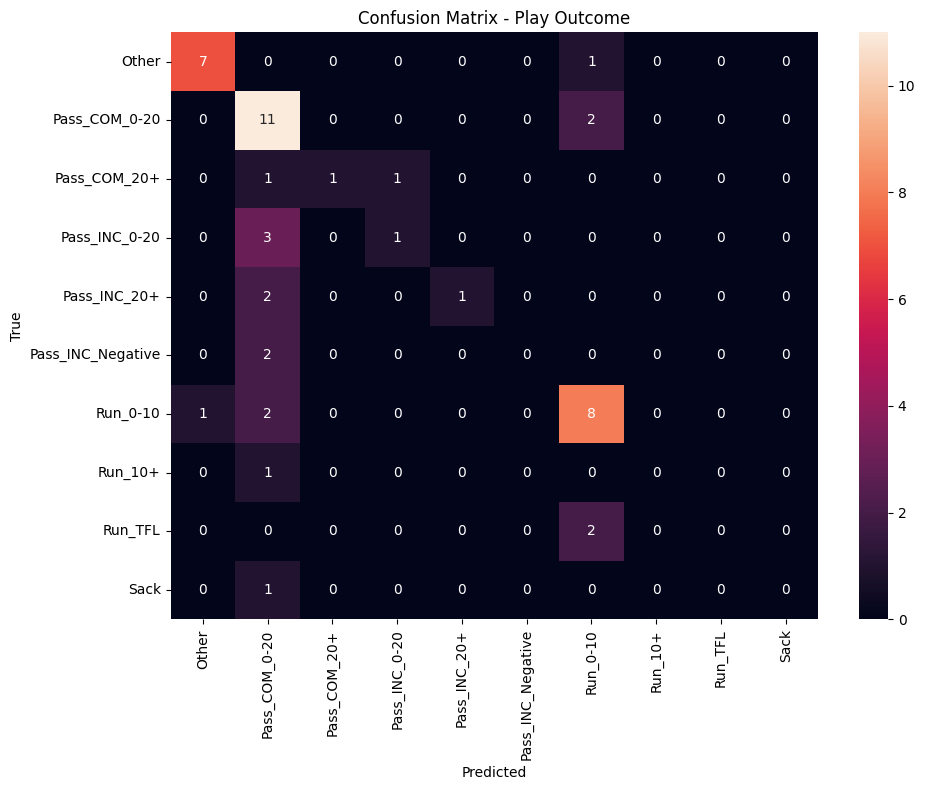

In [12]:
# ============================================================
# 8. Evaluation
# ============================================================

y_val_pred = clf.predict(X_val)
y_val_proba = clf.predict_proba(X_val)

print("Classification report:")
print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=le.classes_
    )
)

cm = confusion_matrix(y_val, y_val_pred)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Play Outcome")
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# 9. Save model & label encoder
# ============================================================

import joblib

OUTPUT_DIR = "./models"
os.makedirs(OUTPUT_DIR, exist_ok=True)

joblib.dump(clf, os.path.join(OUTPUT_DIR, "nfl_play_outcome_xgb.pkl"))
joblib.dump(le, os.path.join(OUTPUT_DIR, "nfl_play_outcome_label_encoder.pkl"))
